<a href="https://colab.research.google.com/github/sabithakrishnan/Survival-Models/blob/main/kapler_Meimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 5.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=02686d6266c2e9fe5dc9e3c5e08102d4a4a2cd5fb0e93f8288d80db7b369ec46
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


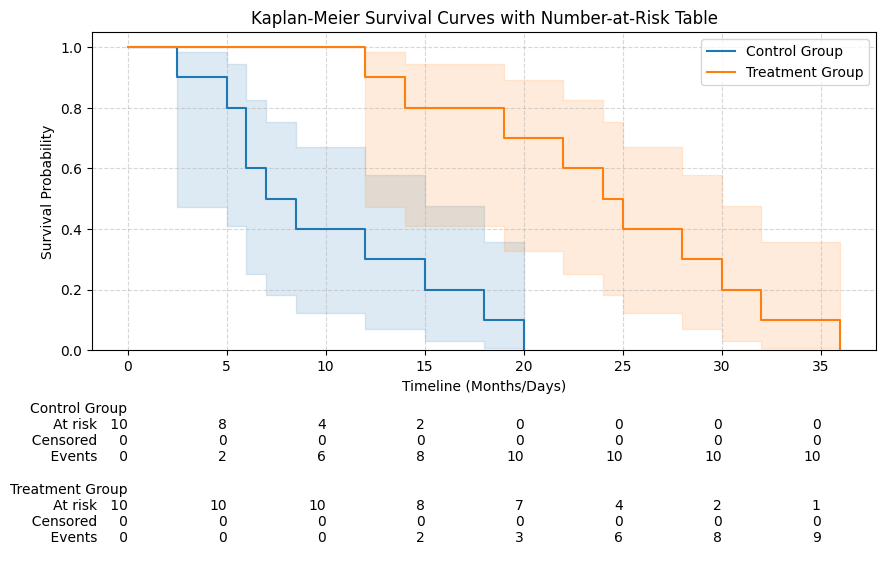

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# 1. Sample comparison data
data = {
    'duration': [5, 6, 6, 2.5, 7, 8.5, 12, 15, 18, 20, 12, 14, 19, 22, 24, 25, 28, 30, 32, 36],
    'event_observed': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'group': ['Control']*10 + ['Treatment']*10
}
df = pd.DataFrame(data)

# Split groups
control = df[df['group'] == 'Control']
treatment = df[df['group'] == 'Treatment']

# 2. Set up subplots (needed to place the at-risk table below the main chart)
fig, ax = plt.subplots(figsize=(9, 6))

# 3. Fit and plot Control Group
kmf_control = KaplanMeierFitter()
kmf_control.fit(control['duration'], event_observed=control['event_observed'], label='Control Group')
kmf_control.plot_survival_function(ax=ax, ci_alpha=0.15, show_censors=True)

# 4. Fit and plot Treatment Group
kmf_treatment = KaplanMeierFitter()
kmf_treatment.fit(treatment['duration'], event_observed=treatment['event_observed'], label='Treatment Group')
kmf_treatment.plot_survival_function(ax=ax, ci_alpha=0.15, show_censors=True)

# 5. Add the Number-at-Risk table
# Pass the fitters to automatically generate and align the table counts below the x-axis
add_at_risk_counts(kmf_control, kmf_treatment, ax=ax)

# 6. Formatting tweaks
ax.set_title('Kaplan-Meier Survival Curves with Number-at-Risk Table')
ax.set_xlabel('Timeline (Months/Days)')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)

# Adjust plot layout so the at-risk table doesn't get cut off
plt.tight_layout()
plt.show()